# TWIX Error Detection - Demo

This notebook demonstrates error detection using TWIX. You can select different PDFs to test with by changing the `PDF_NAME` variable in the configuration cell.


In [ ]:
import os
import json
import twix
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

# Set your OpenAI API key
os.environ['OPENAI_API_KEY'] = 'your-openai-api-key-here'
os.environ['ANTHROPIC_API_KEY'] = 'your-anthropic-api-key-here'


# ============================================================================
# CONFIGURATION: Select which PDF to use
# ============================================================================
# Available PDFs:
#   - 'Investigations_Redacted_modified.pdf'
#   - 'id_10.pdf'
#   - 'id_12.pdf'
#   - 'id_23_29.pdf'
#   - 'id_109_111_112_115_124_126_129_147.pdf'
#   - '22-274.releasable.pdf'
#   - '2137535.pdf'

PDF_NAME = 'Investigations_Redacted_modified.pdf'  # Change this to use a different PDF

root_path = os.path.abspath(os.path.dirname(os.getcwd()))
pdf_path = os.path.join(root_path, 'tests', 'data', PDF_NAME)
pdf_basename = os.path.splitext(PDF_NAME)[0]
result_path = os.path.join(root_path, 'tests', 'out', pdf_basename, '')

print(f"📄 Selected PDF: {PDF_NAME}")
print(f"📁 Result path: {result_path}")


📄 Selected PDF: Investigations_Redacted_modified.pdf
📁 Result path: /Users/jiaweitang/TWIX/tests/out/Investigations_Redacted_modified/


## Step 1: View the PDF Document


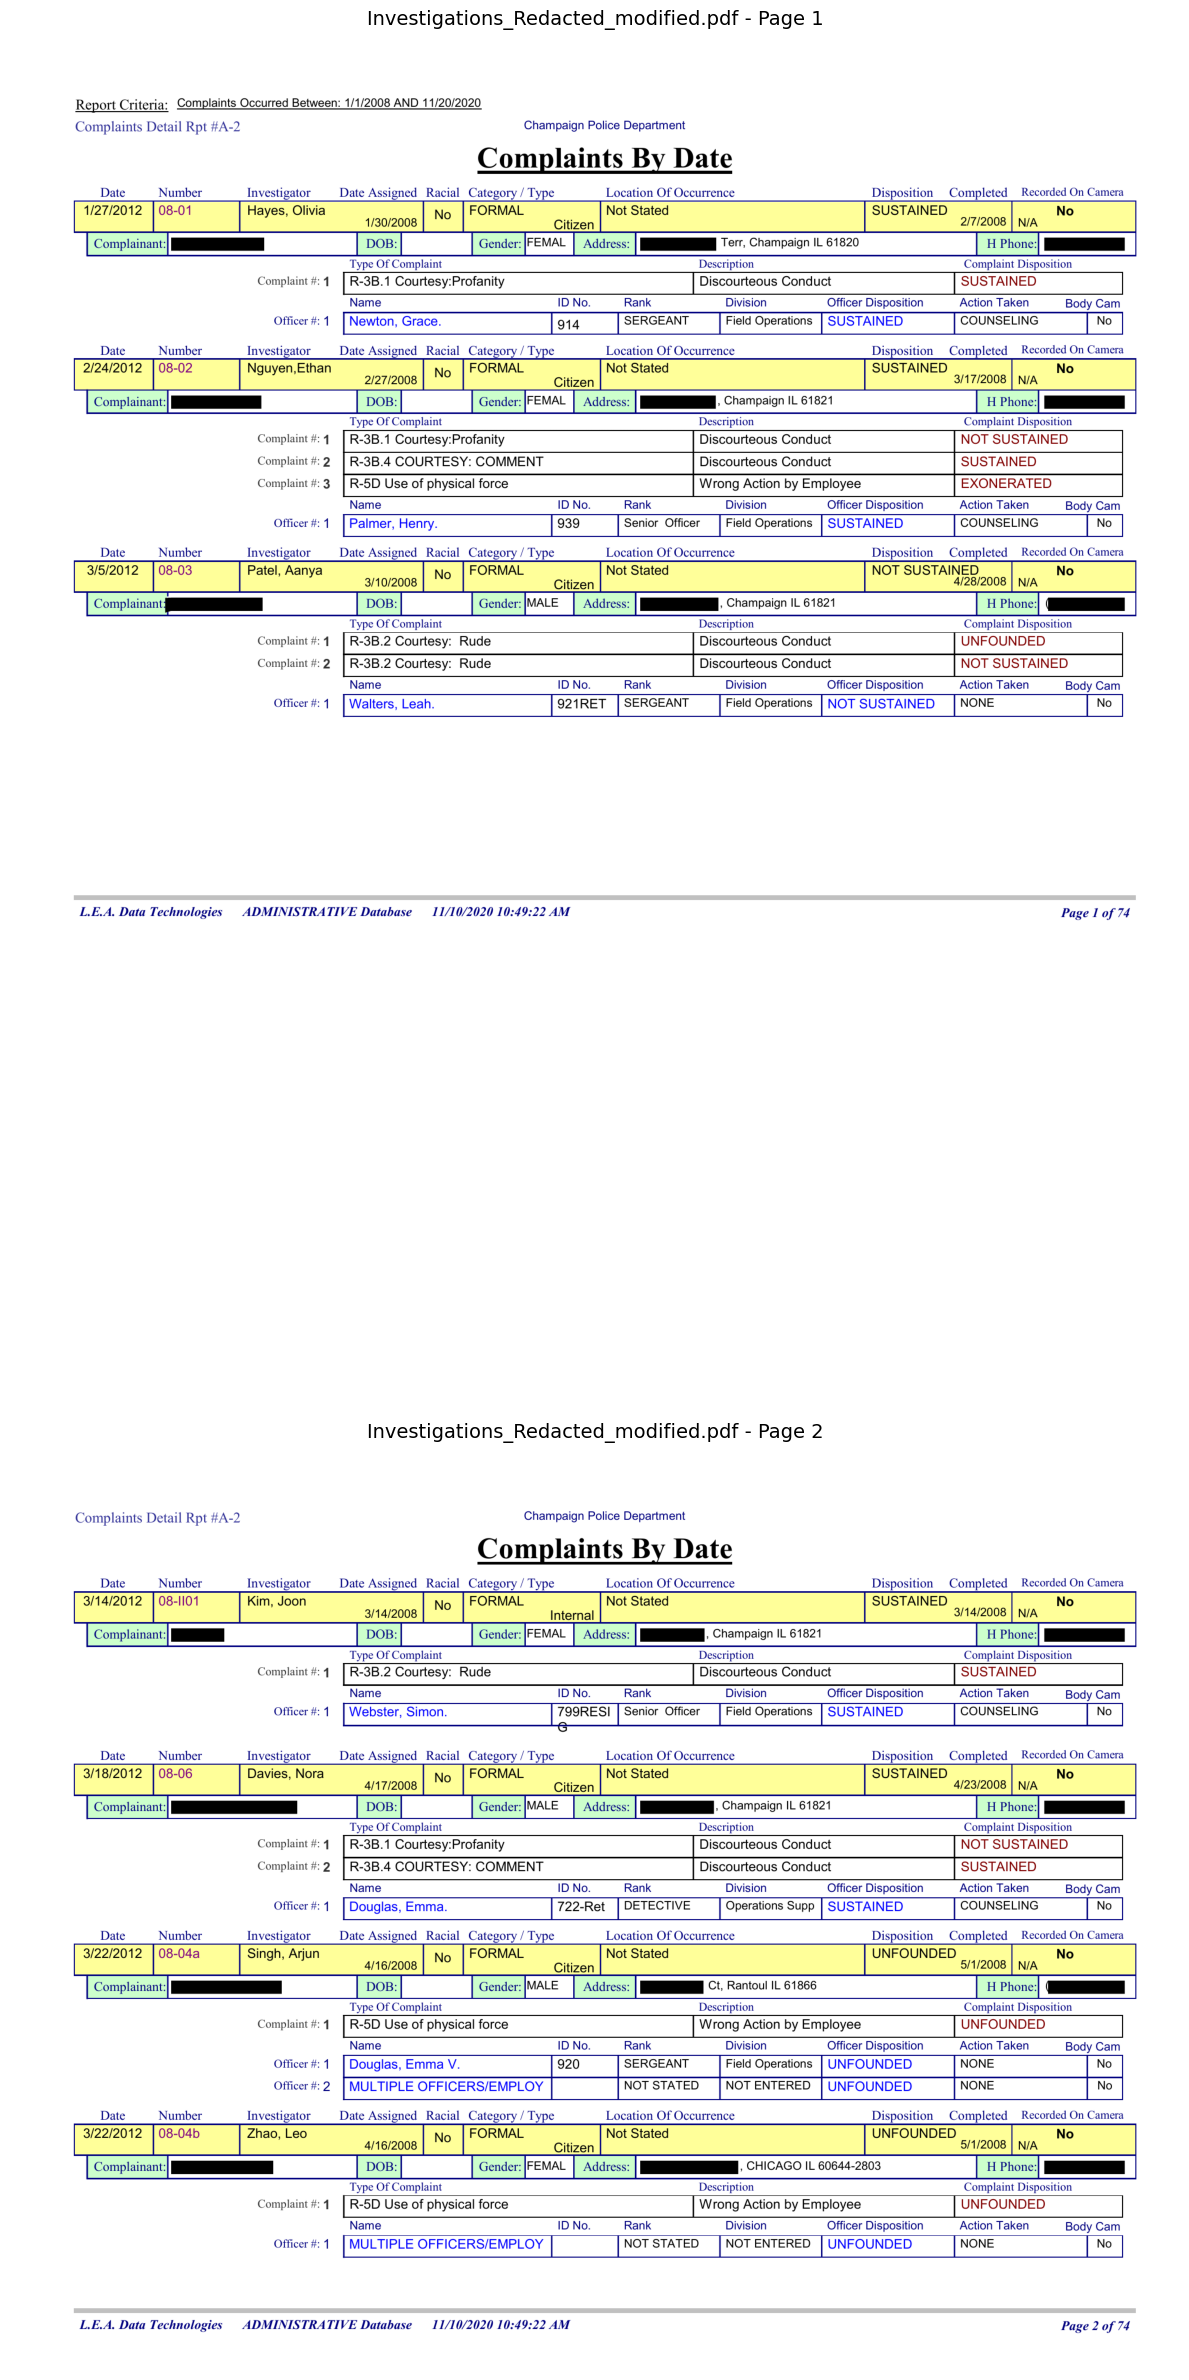

In [9]:
# Display multiple pages of PDF
num_pages = 2
images = convert_from_path(pdf_path, first_page=1, last_page=num_pages)

fig = plt.figure(figsize=(12, 16 * len(images)))

for i, img in enumerate(images):
    plt.subplot(len(images), 1, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{PDF_NAME} - Page {i+1}', fontsize=14, pad=20)

plt.tight_layout()
plt.show()


## Step 2: Run TWIX Extraction

In [10]:
# Run TWIX extraction
pdf_paths = [pdf_path]

print(f"Processing: {PDF_NAME}")
print("Running TWIX extraction...")

fields, template, extraction_output, cost = twix.transform(
    pdf_paths, result_path, 
    LLM_model_name='gpt-4o-mini'
)

file_name = list(extraction_output.keys())[0]
print(f"\nExtraction cost: ${cost:.6f}")
print(f"Records extracted: {len(extraction_output[file_name])}")


Processing: Investigations_Redacted_modified.pdf
Running TWIX extraction...
Phrase extraction starts...
Phrase extraction for the merged file starts...
Phrase extraction for individual files starts...
Field prediction starts...
perfect match starts...
cluster pruning starts...
re-clustering starts...
Template prediction starts...
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 24.6.0 24G90)

CPU model: Apple M2 Max
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 69 rows, 92 columns and 190 nonzeros (Max)
Model fingerprint: 0xe030d1dd
Model has 92 linear objective coefficients
Variable types: 0 continuous, 92 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-03, 7e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -99.8903480
Presolve removed 69 rows and 92 columns
Presolve time: 0.00s
Presolve: All rows a

## Step 3: View Sample Extracted Data


In [11]:
# Show first record
first_record = extraction_output[file_name][0]

print("FIRST EXTRACTED RECORD:")
print("=" * 80)
print(json.dumps(first_record, indent=2)[:1000] + "...")
print("=" * 80)


FIRST EXTRACTED RECORD:
{
  "id": 0,
  "content": [
    {
      "type": "table",
      "content": [
        {
          "Date": "1/27/2012",
          "Number": "08-01",
          "Investigator": "Hayes, Olivia",
          "Date Assigned": "1/30/2008",
          "Racial": "No",
          "Category / Type": "FORMAL",
          "Location Of Occurrence": "Not Stated",
          "Disposition": "SUSTAINED",
          "Completed": "missing",
          "Recorded On Camera": "No"
        },
        {
          "Date": "missing",
          "Number": "missing",
          "Investigator": "missing",
          "Date Assigned": "missing",
          "Racial": "missing",
          "Category / Type": "Citizen",
          "Location Of Occurrence": "missing",
          "Disposition": "missing",
          "Completed": "2/7/2008",
          "Recorded On Camera": "N/A"
        }
      ]
    },
    {
      "type": "kv",
      "content": [
        {
          "Complainant": "missing"
        },
        {
    

## Step 4: Run Error Detection with VIsion Model


In [12]:
# Run error detection with vision
print("📄 Converting PDF to images...")
analysis = twix.detect_errors(
    extraction_output=extraction_output,
    pdf_path=pdf_path,
    max_pages=3,
    max_records=3
)

print(f"\n📊 Results:")
print(f"  • Errors found: {analysis['error_count']}")
print(f"  • Detection cost: ${analysis['cost']:.6f}")


📄 Converting PDF to images...
🔍 Analyzing 3 PDF page(s) with vision-claude-sonnet...
✓ Found 14 error(s) | Cost: $0.0454

📊 Results:
  • Errors found: 14
  • Detection cost: $0.045420


## Step 5: View Error Report


In [15]:
import pandas as pd
from IPython.display import display, HTML

def display_error_report(analysis_result):
    """Display error detection results as formatted tables"""
    errors = analysis_result.get('errors', [])
    error_count = analysis_result.get('error_count', 0)
    cost = analysis_result.get('cost', 0)
    
    # Summary
    print("=" * 70)
    print("TWIX ERROR DETECTION REPORT")
    print("=" * 70)
    print(f"\n📊 Total Errors: {error_count}  |  💰 Analysis Cost: ${cost:.6f}\n")
    
    if not errors:
        print("✅ No errors detected!")
        return
    
    # Count errors by type
    error_types = {}
    for error in errors:
        error_type = error.get('error_type', 'UNKNOWN')
        error_types[error_type] = error_types.get(error_type, 0) + 1
    
    # Summary table
    summary_df = pd.DataFrame([
        {'Error Type': k, 'Count': v} for k, v in error_types.items()
    ])
    print("📋 ERRORS BY TYPE:")
    display(summary_df.style.set_properties(**{'text-align': 'left'}))
    
    # Detailed errors table
    errors_df = pd.DataFrame([
        {
            '#': i + 1,
            'Type': error.get('error_type', 'UNKNOWN'),
            'Field': error.get('field', 'N/A'),
            'Current Value': error.get('current_value', 'N/A'),
            'Expected Value': error.get('expected_value', 'N/A'),
            'Location': error.get('location', 'N/A')
        }
        for i, error in enumerate(errors)
    ])
    
    print("\n🔍 DETAILED ERRORS:")
    display(errors_df.style.set_properties(**{'text-align': 'left'}))
    
    return errors_df

# Display the report as tables
errors_df = display_error_report(analysis)

# Optionally save report to file (CSV for table format)
report_path = result_path + 'error_report.txt'
csv_path = result_path + 'error_report.csv'

# Save as CSV
if errors_df is not None:
    errors_df.to_csv(csv_path, index=False)
    print(f"\n📄 CSV saved: {csv_path}")

# Also save text version
with open(report_path, 'w') as f:
    f.write(f"TWIX ERROR DETECTION REPORT\n")
    f.write(f"Total Errors: {analysis['error_count']}\n")
    f.write(f"Analysis Cost: ${analysis['cost']:.6f}\n\n")
    if errors_df is not None:
        f.write(errors_df.to_string(index=False))
print(f"📄 Report saved: {report_path}")


TWIX ERROR DETECTION REPORT

📊 Total Errors: 14  |  💰 Analysis Cost: $0.045420

📋 ERRORS BY TYPE:


,Error Type,Count
0,VALUE_WRONG,6
1,VALUE_MISSING,8



🔍 DETAILED ERRORS:


,#,Type,Field,Current Value,Expected Value,Location
0,1,VALUE_WRONG,Complaint # 1 - Type Of Complaint,R-3B.1 Courtesy,R-3B.1 Courtesy-Profanity,"Page 1, Complaint 08-01"
1,2,VALUE_WRONG,Complaint # 1 - Type Of Complaint,R-3B.1 Courtesy,R-3B.1 Courtesy:Profanity,"Page 2, Complaint 08-02"
2,3,VALUE_WRONG,Complaint # 2 - Type Of Complaint,R-3B.4 COURTESY,R-3B.4 COURTESY: COMMENT,"Page 2, Complaint 08-02"
3,4,VALUE_WRONG,Rank,Senior,Senior Officer,"Page 2, Complaint 08-02, Officer Palmer, Henry."
4,5,VALUE_MISSING,Date,missing,3/5/2012,"Page 2, Complaint 08-03"
5,6,VALUE_MISSING,Number,missing,08-03,"Page 2, Complaint 08-03"
6,7,VALUE_MISSING,Investigator,missing,"Patel, Aanya","Page 2, Complaint 08-03"
7,8,VALUE_MISSING,Date Assigned,missing,3/10/2008,"Page 2, Complaint 08-03"
8,9,VALUE_MISSING,Racial,missing,No,"Page 2, Complaint 08-03"
9,10,VALUE_MISSING,Category / Type,Citizen,FORMAL,"Page 2, Complaint 08-03"



📄 CSV saved: /Users/jiaweitang/TWIX/tests/out/Investigations_Redacted_modified/error_report.csv
📄 Report saved: /Users/jiaweitang/TWIX/tests/out/Investigations_Redacted_modified/error_report.txt


In [16]:
twix.visualize_extraction(extraction_output, max_records=3)


FILE: Investigations_Redacted_modified
TOTAL RECORDS: 75


────────────────────────────────────────────────────────────────────────────────
RECORD ID: 0
────────────────────────────────────────────────────────────────────────────────

[Table 1]


,Date,Number,Investigator,Date Assigned,Racial,Category / Type,Location Of Occurrence,Disposition,Completed,Recorded On Camera
0,1/27/2012,08-01,"Hayes, Olivia",1/30/2008,No,FORMAL,Not Stated,SUSTAINED,missing,No
1,missing,missing,missing,missing,missing,Citizen,missing,missing,2/7/2008,N/A



[Key-Value 2]


,Value
Complainant,missing
DOB,missing
Gender,FEMAL
Address,"Terr, Champaign IL 61820"
H Phone,missing



[Table 3]


...

,Value
Complainant,missing
DOB,missing
Gender,MALE
Address,", Champaign IL 61821"
H Phone,(



[Table 3]


,Type Of Complaint,Description,Complaint Disposition
0,R-3B.2 Courtesy,Discourteous Conduct,UNFOUNDED
1,R-3B.2 Courtesy,Discourteous Conduct,NOT SUSTAINED



[Table 4]


,Name,ID No.,Rank,Division,Officer Disposition,Action Taken,Body Cam
0,"Walters, Leah.",921RET,SERGEANT,Field Operations,NOT SUSTAINED,NONE,No
